In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import re
import pandas as pd
from transformers import AutoTokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

import os
files = os.listdir(path)
print(files)

Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
['fashion-dataset']


In [4]:
main_path = os.path.join(path, "fashion-dataset")

print(os.listdir(main_path))

['images.csv', 'images', 'styles.csv', 'styles', 'fashion-dataset']


In [5]:
df = pd.read_csv(main_path + "/styles.csv", on_bad_lines="skip")
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [6]:
df['image_path'] = df['id'].astype(str).apply(lambda x: main_path + "/images/" + x + ".jpg")

In [7]:
print(df.head())

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  \
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt   
1  2012.0  Casual             Peter England Men Party Blue Jeans   
2  2016.0  Casual                       Titan Women Silver Watch   
3  2011.0  Casual  Manchester United Men Solid Black Track Pants   
4  2012.0  Casual                          Puma Men Grey T-shirt   

                                          image_path  
0  /kaggle/input/fashion-product-images-dataset/f...  
1  /kaggle/i

In [8]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/fashion-product-images-dataset/f...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,/kaggle/input/fashion-product-images-dataset/f...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,/kaggle/input/fashion-product-images-dataset/f...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,/kaggle/input/fashion-product-images-dataset/f...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,/kaggle/input/fashion-product-images-dataset/f...


In [9]:
df[df["baseColour"].isnull() == True]

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
6206,11293,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Blue Texas Jeans,/kaggle/input/fashion-product-images-dataset/f...
9516,41347,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Black Texas Jeans,/kaggle/input/fashion-product-images-dataset/f...
12763,11288,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Blue Texas Jeans,/kaggle/input/fashion-product-images-dataset/f...
14291,30991,Women,Personal Care,Fragrance,Perfume and Body Mist,NaN,Spring,2017.0,NaN,NaN,/kaggle/input/fashion-product-images-dataset/f...
15526,57698,Women,Personal Care,Skin,Face Moisturisers,NaN,Spring,2017.0,Casual,Lotus Herbals Quincenourish Quince Seed Nouris...,/kaggle/input/fashion-product-images-dataset/f...
15708,41355,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Blue Millard Jeans,/kaggle/input/fashion-product-images-dataset/f...
17268,43122,Men,Personal Care,Fragrance,Perfume and Body Mist,NaN,Spring,2017.0,NaN,GUESS Man Eau De Toilette 75 ml,/kaggle/input/fashion-product-images-dataset/f...
17639,45687,Men,Personal Care,Fragrance,Perfume and Body Mist,NaN,Spring,2017.0,NaN,NaN,/kaggle/input/fashion-product-images-dataset/f...
20209,11309,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Blue Floyd Jeans,/kaggle/input/fashion-product-images-dataset/f...
23484,45698,Women,Personal Care,Fragrance,Perfume and Body Mist,NaN,Spring,2017.0,NaN,NaN,/kaggle/input/fashion-product-images-dataset/f...


In [10]:
colors = df["baseColour"].dropna().unique()

In [11]:
colors = [c.lower for c in colors]

In [12]:

colors = df['baseColour'].dropna().astype(str).str.lower().unique().tolist()
colors = sorted(colors, key=len, reverse=True)
def extract_color(text):
    if pd.isna(text):
        return None

    text = str(text).lower()

    for color in colors:
        pattern = rf"\b{re.escape(color)}\b"
        if re.search(pattern, text):
            return color.title()

    return None

first = df['baseColour'].isnull().sum()
second = df['baseColour'].isnull().sum()

mask = df['baseColour'].isnull()

df.loc[mask, 'baseColour'] = df.loc[mask, 'productDisplayName'].apply(extract_color)


In [13]:
mask = (
    (df["masterCategory"] == "Personal Care") &
    (df["subCategory"] == "Fragrance") &
    (df["usage"].isnull())
)

df.loc[mask, "usage"] = "Casual"

In [14]:
mask_group = (
    (df["masterCategory"] == "Personal Care") &
    (df["subCategory"] == "Fragrance")
)
mode_color = df.loc[mask_group, "baseColour"].mode()[0]
mask_fill = mask_group & df["baseColour"].isnull()
df.loc[mask_fill, "baseColour"] = mode_color


In [15]:
df["usage"] = df["usage"].fillna(
    df.groupby(["masterCategory", "subCategory"])["usage"]
      .transform(lambda x: x.mode()[0] if not x.mode().empty else None)
)

In [16]:
df["year"].fillna("2011", inplace=True)
df[
    (df["usage"] == "Sports") &
    (df["subCategory"] == "Shoes")
]["season"].value_counts()
df["season"].fillna("Summer",inplace=True)
df["year"] = df["year"].astype(int)

/tmp/ipykernel_9332/4125030073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["year"].fillna("2011", inplace=True)
/tmp/ipykernel_9332/4125030073.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2011' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df["year"].fillna("2011", inplace=True)
/tmp/ipykernel_9332/4125030073.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame o

In [17]:
def build_name(row):
    parts = [
        str(row.get("brandName", "")),
        str(row.get("gender", "")),
        str(row.get("baseColour", "")),
        str(row.get("articleType", "")),
        str(row.get("usage", ""))
    ]
    parts = [p for p in parts if p and p != "nan"]
    return " ".join(parts)

In [18]:
mask = df["productDisplayName"].isnull()

df.loc[mask, "productDisplayName"] = df.loc[mask].apply(build_name, axis=1)

In [19]:
df.isnull().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,0
season,0
year,0
usage,0
productDisplayName,0


In [20]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

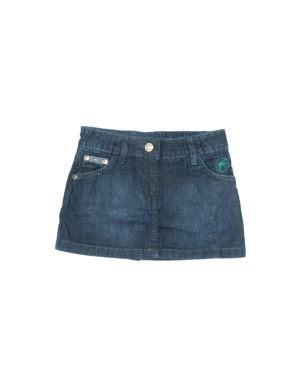

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import os
image_path = os.path.join(path, 'fashion-dataset', 'fashion-dataset', 'images', '10002.jpg')
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [22]:
df.shape

(44424, 11)

In [23]:
df.isnull().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,0
season,0
year,0
usage,0
productDisplayName,0


sütunun bert oxuya bilsin deyə temiz hala salinmasi

In [24]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_product_name"] = df["productDisplayName"].apply(clean_text)

In [25]:
df[["productDisplayName", "clean_product_name"]].head()

,productDisplayName,clean_product_name
0,Turtle Check Men Navy Blue Shirt,turtle check men navy blue shirt
1,Peter England Men Party Blue Jeans,peter england men party blue jeans
2,Titan Women Silver Watch,titan women silver watch
3,Manchester United Men Solid Black Track Pants,manchester united men solid black track pants
4,Puma Men Grey T-shirt,puma men grey t shirt


In [26]:
def build_bert_text(row):
    name = str(row["clean_product_name"]).lower()

    extra = []
    if pd.notna(row["gender"]) and row["gender"].lower() not in name:
        extra.append(row["gender"].lower())
    if pd.notna(row["usage"]) and row["usage"].lower() not in name:
        extra.append(row["usage"].lower())
    if pd.notna(row["season"]) and row["season"].lower() not in name:
        extra.append(row["season"].lower())
    if pd.notna(row["baseColour"]) and row["baseColour"].lower() not in name:
        extra.append(row["baseColour"].lower())

    return name + " " + " ".join(extra)

In [27]:
df.loc[:, "bert_text"] = df.apply(build_bert_text, axis=1)
df["bert_text"] = df["bert_text"].apply(clean_text)
df["bert_text"]
target_col = "masterCategory"

Encoding

In [28]:
le=LabelEncoder()
df["label"] = le.fit_transform(df[target_col])
num_classes = df["label"].nunique()
df_model = df[["bert_text","image_path", "label"]].copy()

df_model = df_model.dropna(subset=["bert_text","image_path" ,"label"])
df_model = df_model[df_model["bert_text"].str.strip() != ""]

In [29]:
min_samples = 20

class_counts = df_model["label"].value_counts()
valid_classes = class_counts[class_counts >= min_samples].index

df_model = df_model[df_model["label"].isin(valid_classes)].copy()
le = LabelEncoder()
df_model["label"] = le.fit_transform(df_model["label"])
num_classes = df_model["label"].nunique()
print(num_classes)
print(le.classes_)

6
[0 1 2 3 5 6]


In [30]:
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model["label"],
    random_state=42
)

In [31]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [32]:
sample_text = train_df["bert_text"].iloc[0]

encoding = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=64,
    return_tensors="pt"           )


In [33]:
from torch.utils.data import Dataset
from PIL import Image

class ProductDataset(Dataset):
    def __init__(self, df, tokenizer, image_transform=None, max_len=64):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer  #BERT
        self.image_transform = image_transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        if self.image_transform:
            image = self.image_transform(image)

        encoding = self.tokenizer(
            row["bert_text"],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "image": image,
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }

In [34]:
from torchvision import transforms

image_transform = transforms.Compose([
    transforms.Resize((224, 224)), #Bütün şəkilləri eyni ölçüyə salır
    transforms.ToTensor(),     #Şəkli PyTorch tensoruna çevirir və pixel dəyərlərini 0-1 aralağına salır
    transforms.Normalize(   #Şekli standartlaşdırıq
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [35]:
from torch.utils.data import DataLoader      #Data paylayan mexanizm

train_dataset = ProductDataset(train_df, tokenizer, image_transform)
test_dataset = ProductDataset(test_df, tokenizer, image_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [36]:
import torch
batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["label"].shape)

torch.Size([16, 3, 224, 224])
torch.Size([16, 64])
torch.Size([16, 64])
torch.Size([16])


In [37]:
import torch
import torch.nn as nn
from torchvision import models
from transformers import AutoModel

class MultiModalClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.image_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)  #ResNet50 yüklənir
        self.image_model.fc = nn.Identity()

        self.text_model = AutoModel.from_pretrained("bert-base-uncased")

        self.classifier = nn.Sequential(   #Modelin son qərar verən hissəsi
            nn.Linear(2048 + 768, 512),  #şəkil (2048) + mətn (768)---->birləşdirilir → 2816----->512 ölçüyə salınır
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, image, input_ids, attention_mask):
        image_features = self.image_model(image)

        text_outputs = self.text_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_outputs.pooler_output

        combined = torch.cat((image_features, text_features), dim=1)

        return self.classifier(combined)

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiModalClassifier(num_classes).to(device)

criterion = nn.CrossEntropyLoss()        #Loss function
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5) #0.00002  learning rate

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 79.1MB/s]


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
batch = next(iter(train_loader))

images = batch["image"].to(device)
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

outputs = model(images, input_ids, attention_mask)

print(outputs.shape)

torch.Size([16, 6])


In [40]:
class FashionDataset(Dataset):
    def __init__(self, df, img_dir, skip_missing=True):
        self.df = df
        self.img_dir = Path(img_dir)
        self.skip_missing = skip_missing

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / row["image_path"]

        if not img_path.exists():
            if self.skip_missing:
                # Random başqa row-u return et
                return self[np.random.randint(0, len(self))]
            else:
                raise FileNotFoundError(f"{img_path}")

        image = Image.open(img_path).convert("RGB")
        # ... rest of processing

In [41]:
import os
from pathlib import Path
import kagglehub

# Download
img_dir = Path(kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset"))

# Train filtir
before = len(train_df)
train_df = train_df[train_df["image_path"].apply(lambda x: (img_dir / x).exists())].reset_index(drop=True)
after = len(train_df)
print(f"Train: {before} → {after} ✓" if after == before else f"Train: {before} → {after} (Missing: {before-after})")

# Test/Val filtir (əgər mövcuddursa)
if 'test_df' in locals():
    before_test = len(test_df)
    test_df = test_df[test_df["image_path"].apply(lambda x: (img_dir / x).exists())].reset_index(drop=True)
    after_test = len(test_df)
    print(f"Test: {before_test} → {after_test} ✓" if after_test == before_test else f"Test: {before_test} → {after_test} (Missing: {before_test-after_test})")

elif 'val_df' in locals():
    before_val = len(val_df)
    val_df = val_df[val_df["image_path"].apply(lambda x: (img_dir / x).exists())].reset_index(drop=True)
    after_val = len(val_df)
    print(f"Val: {before_val} → {after_val} ✓" if after_val == before_val else f"Val: {before_val} → {after_val} (Missing: {before_val-after_val})")

# Test DataLoader
train_dataset = FashionDataset(train_df, img_dir=str(img_dir))
train_loader = DataLoader(train_dataset, batch_size=32)

try:
    batch = next(iter(train_loader))
    print(f"✓ DataLoader OK: images {batch['image'].shape}, text {batch['input_ids'].shape}")
except Exception as e:
    print(f"✗ Error: {e}")

Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Train: 35538 → 35534 (Missing: 4)
Test: 8885 → 8884 (Missing: 1)
✗ Error: object of type 'FashionDataset' has no len()


Model Building
loosun tapılması



In [42]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
import torch
from torchvision import transforms
from tqdm import tqdm

class FashionDataset(Dataset):
    def __init__(self, df, img_dir, tokenizer, image_transform, max_len=64):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_filename = row["image_path"].split("/")[-1]
        img_path = self.img_dir / img_filename

        if not img_path.exists():
            image = torch.zeros(3, 224, 224)
        else:
            try:
                image = Image.open(img_path).convert("RGB")
                image = self.image_transform(image)
            except:
                image = torch.zeros(3, 224, 224)

        text = str(row["bert_text"])
        encoding = self.tokenizer(
            text, padding="max_length", truncation=True,
            max_length=self.max_len, return_tensors="pt"
        )

        return {
            "image": image,
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }

# Dataset yarat
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = FashionDataset(train_df, str(img_dir), tokenizer, image_transform)
test_dataset = FashionDataset(test_df, str(img_dir), tokenizer, image_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

# Training
epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f}")

Train: 35534, Test: 8884


Epoch 1/3: 100%|██████████| 2221/2221 [15:02<00:00,  2.46it/s, loss=0.00196]


Epoch 1 | Train Loss: 0.0862


Epoch 2/3: 100%|██████████| 2221/2221 [14:48<00:00,  2.50it/s, loss=0.00277]


Epoch 2 | Train Loss: 0.0227


Epoch 3/3: 100%|██████████| 2221/2221 [14:41<00:00,  2.52it/s, loss=0.00599]

Epoch 3 | Train Loss: 0.0200


In [43]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images, input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating: 100%|██████████| 556/556 [01:08<00:00,  8.08it/s]


In [44]:
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print("Macro F1:", macro_f1)

Macro F1: 0.16798077108897994


In [45]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=[str(c) for c in le.classes_]
))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2255
           1       1.00      0.64      0.78      4278
           2       0.00      0.00      0.00      1844
           3       0.01      0.57      0.01        21
           5       0.12      1.00      0.22       481
           6       0.00      0.00      0.00         5

    accuracy                           0.36      8884
   macro avg       0.19      0.37      0.17      8884
weighted avg       0.49      0.36      0.39      8884



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(le.classes_, class_acc):
    print(f"{cls}: {acc:.4f}")

0: 0.0000
1: 0.6398
2: 0.0000
3: 0.5714
5: 1.0000
6: 0.0000
